# Exercício:

## 01 – Do exercício 2 da aula 15, exporte o objeto DataFrame contendo as frequências absolutas de cada aminoácido em cada proteína para .csv, instancie um objeto da classe DataFrame. Defina uma função que receba qualquer objeto composto unidimensional e que retorne as medidas de tendência central. Qual o valor de média, mediana e moda da Serina nos genes analisados? E do terceiro gene?

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("frequencias.csv")
def medidas_tendencia(dados):
    media = dados.mean()
    mediana = dados.median()
    moda = dados.mode()
    
    return media, mediana, moda

In [3]:
media, mediana, moda = medidas_tendencia(df['S'])

print(f"Média: {media}")
print(f"Mediana: {mediana}")
print(f"Moda: {moda.values}")

Média: 96.6
Mediana: 84.0
Moda: [ 14  38  84 123 224]


In [4]:
terceiro_gene = df.iloc[2]['S']
print(f"Serinas no terceiro gene: {terceiro_gene}")

Serinas no terceiro gene: 84


## 02 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne a amplitude. Qual o valor de amplitude da Isoleucina? E do último gene?

In [5]:
def amplitude(dados):
    return dados.max() - dados.min()

In [6]:
amp_I = amplitude(df['I'])

print(f"Amplitude da Isoleucina: {amp_I}")

Amplitude da Isoleucina: 117


In [7]:
ultimo_gene = df.iloc[-1]

amp_ultimo = amplitude(ultimo_gene.drop('gene'))

print(f"Amplitude do último gene: {amp_ultimo}")

Amplitude do último gene: 40


## 03 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne os quartis. Qual o valor do Q1, Q2 e Q3 da Metionina? E do primeiro gene?

In [8]:
def calcular_quartis(dados):
    q1 = dados.quantile(0.25)
    q2 = dados.quantile(0.50)
    q3 = dados.quantile(0.75)
    
    return q1, q2, q3

In [9]:
q1, q2, q3 = calcular_quartis(df['M'])

print(f"Metionina (M):")
print(f"Q1: {q1}")
print(f"Q2: {q2}")
print(f"Q3: {q3}")

Metionina (M):
Q1: 12.0
Q2: 25.0
Q3: 30.0


In [10]:
primeiro_gene = df.iloc[0].drop('gene')

q1g, q2g, q3g = calcular_quartis(primeiro_gene)

print(f"\nPrimeiro gene: {df.iloc[0]['gene']}")
print(f"Q1: {q1g}")
print(f"Q2: {q2g}")
print(f"Q3: {q3g}")


Primeiro gene: BRCA1
Q1: 49.0
Q2: 87.0
Q3: 111.0


## 04 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne o intervalo interquartil. Qual o valor do o intervalo interquartil da Ácido Glutâmico? E do penúltimo gene? Obtenha o box plot com as medidas de tendência central para a frequência de aa nesse gene.

In [11]:
def intervalo_interquartil(dados):
    return dados.quantile(0.75) - dados.quantile(0.25)

In [12]:
iqr_E = intervalo_interquartil(df['E'])

print(f"IQR do Ácido Glutâmico (E): {iqr_E}")

IQR do Ácido Glutâmico (E): 53.0


In [13]:
penultimo = df.iloc[-2]
dados_gene = penultimo.drop('gene')
iqr_gene = intervalo_interquartil(dados_gene)

print(f"\nPenúltimo gene: {df.iloc[-2]['gene']}")
print(f"Intervalo interquartil: {iqr_gene}")


Penúltimo gene: CFTR
Intervalo interquartil: 45.0


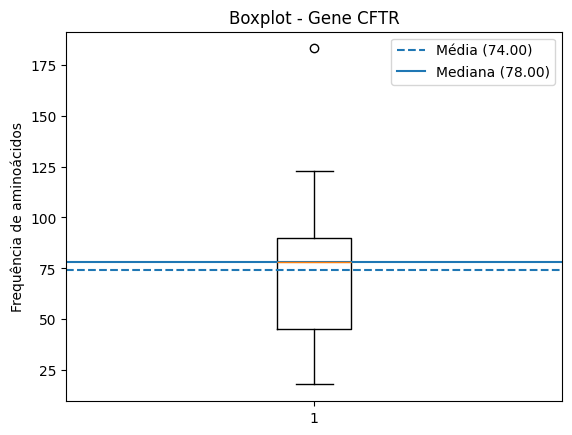

In [14]:
import matplotlib.pyplot as plt

media = dados_gene.mean()
mediana = dados_gene.median()

plt.figure()
plt.boxplot(dados_gene)

plt.axhline(media, linestyle='--', label=f'Média ({media:.2f})')
plt.axhline(mediana, linestyle='-', label=f'Mediana ({mediana:.2f})')

plt.title(f"Boxplot - Gene {df.iloc[-2]['gene']}")
plt.ylabel("Frequência de aminoácidos")

plt.legend()
plt.show()

## 05 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne a variância amostral não viciada. Qual o valor da variância da Prolina? E do terceiro gene?

In [15]:
def variancia_nao_viciada(dados):
    return dados.var(ddof=1)

In [16]:
var_prolina = variancia_nao_viciada(df['P'])

print(f"Variância da Prolina (P): {var_prolina}")

Variância da Prolina (P): 1120.7


In [17]:
terceiro_gene = df.iloc[2]

dados_gene = terceiro_gene.drop('gene')
var_gene = variancia_nao_viciada(dados_gene)

print(f"\nTerceiro gene: {df.iloc[2]['gene']}")
print(f"Variância: {var_gene}")


Terceiro gene: EGFR
Variância: 513.65


## 06 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne o desvio padrão. Qual o valor d o desvio padrão do Triptofano? E do gene de index -1?

In [18]:
def desvio_padrao(dados):
    return dados.std(ddof=1)

In [19]:
dp_W = desvio_padrao(df['W'])

print(f"Desvio padrão do Triptofano (W): {dp_W}")

Desvio padrão do Triptofano (W): 7.162401831787993


In [20]:
ultimo_gene = df.iloc[-1]
dados_gene = ultimo_gene.drop('gene')
dp_gene = desvio_padrao(dados_gene)

print(f"\nGene: {df.iloc[-1]['gene']}")
print(f"Desvio padrão: {dp_gene}")


Gene: APOE
Desvio padrão: 13.646519702839988


## 07 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne o coeficiente de variação. Qual o valor do coeficiente de variação da Leucina? E do gene de index 1?

In [21]:
def coef_variacao(dados):
    return (dados.std(ddof=1) / dados.mean()) * 100

In [22]:
cv_L = coef_variacao(df['L'])

print(f"Coeficiente de variação da Leucina (L): {cv_L}")

Coeficiente de variação da Leucina (L): 64.39011482038536


In [23]:
gene1 = df.iloc[1]
dados_gene = gene1.drop('gene')
cv_gene = coef_variacao(dados_gene)

print(f"\nGene: {df.iloc[1]["gene"]}")
print(f"Coeficiente de variação: {cv_gene}")


Gene: TP53
Coeficiente de variação: 52.7712303288683


## 08 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne as medidas resumo.
Obs.: Use um dicionário onde os index são os nomes e os valores as medidas.

In [24]:
def medidas_resumo(dados):
    resumo = {
        "media": dados.mean(),
        "mediana": dados.median(),
        "moda": list(dados.mode()),
        "variancia": dados.var(ddof=1),
        "desvio_padrao": dados.std(ddof=1),
        "minimo": dados.min(),
        "maximo": dados.max()
    }
    
    return resumo

In [25]:
resumo_S = medidas_resumo(df['S'])

print("Serina (S):")
for k, v in resumo_S.items():
    print(f"{k}: {v}")

Serina (S):
media: 96.6
mediana: 84.0
moda: [14, 38, 84, 123, 224]
variancia: 6835.799999999999
desvio_padrao: 82.67889694474643
minimo: 14
maximo: 224


## 09 – Defina uma função que retorne qual o gene com o maior CV de frequência de aminoácidos. Obtenha os boxplot dos genes. Os dados concordam? Porque?

In [26]:
def gene_maior_cv(df):
    dados = df.set_index('gene')
    cvs = (dados.std(axis=1, ddof=1) / dados.mean(axis=1)) * 100
    gene_max = cvs.idxmax()
    return gene_max, cvs

In [27]:
gene_max, cvs = gene_maior_cv(df)

print(f"Gene com maior CV: {gene_max}")
print(f"CV: {cvs[gene_max]}")

Gene com maior CV: APOE
CV: 86.09791610624598


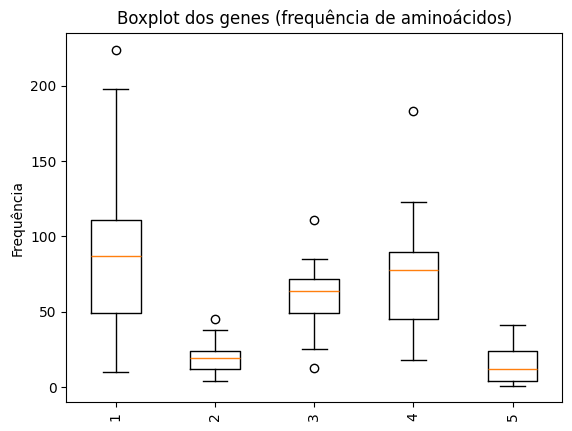

In [28]:
dados_box = df.drop(columns=['gene'])

plt.figure()
plt.boxplot(dados_box.T)

plt.title("Boxplot dos genes (frequência de aminoácidos)")
plt.ylabel("Frequência")
plt.xticks(rotation=90)

plt.show()

Os dados não concordam plenamente, pois o coeficiente de variação (CV) indica a variabilidade relativa dos dados, enquanto o boxplot representa a dispersão baseada em quartis. Nos resultados, é possível observar essa diferença, já que o gene com maior CV foi “APOE”, porém, no boxplot, ele não apresentou a maior dispersão entre os genes analisados.

## 10 – Defina uma função que retorne qual o aminoácidos com o maior CV dentre os genes. Obtenha os boxplot dos aminoácidos. Os dados concordam? Porque?

In [32]:
def aminoacido_maior_cv(df):

    # remove a coluna dos genes
    dados = df.drop(columns=['gene'])

    # calcula CV de cada aminoácido (por coluna)
    cvs = (dados.std(ddof=1) / dados.mean()) * 100

    # pega o aminoácido com maior CV
    aa_max = cvs.idxmax()

    return aa_max, cvs

aa_max, cvs = aminoacido_maior_cv(df)

print("Aminoácido com maior CV:", aa_max)


Aminoácido com maior CV: N


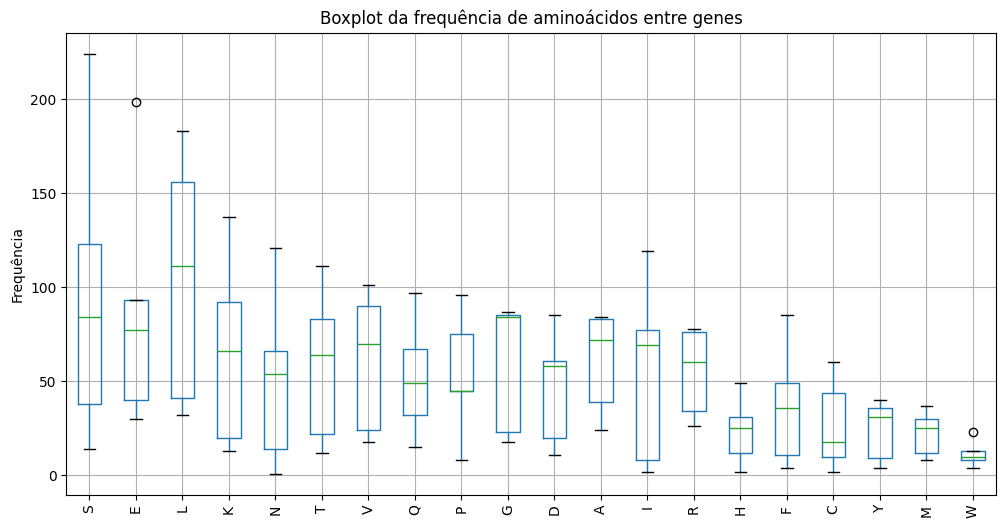

In [31]:
dados = df.drop(columns=['gene', 'media_aa'])

plt.figure(figsize=(12,6))
dados.boxplot()

plt.xticks(rotation=90)
plt.title("Boxplot da frequência de aminoácidos entre genes")
plt.ylabel("Frequência")

plt.show()

O aminoácido com maior coeficiente de variação (CV) foi a asparagina (N). No entanto, no boxplot, ela não apresentou a maior dispersão visual entre todos os aminoácidos. Isso ocorre porque o CV mede a variabilidade relativa dos dados, sendo influenciado pela relação entre o desvio padrão e a média. Já o boxplot representa a dispersão baseada em quartis e mediana, sendo menos sensível a variações relativas e mais robusto a outliers. Dessa forma, é possível que um aminoácido tenha alto CV sem necessariamente apresentar a maior dispersão no boxplot, devido às diferenças entre as métricas utilizadas.